## **Assignment: "The Visual Inspector" — CNN Fundamentals**

**The Scenario**

You have just joined "VisionCore AI" as a Computer Vision Engineer. Your manager hands you a grayscale image classification pipeline that uses a plain MLP — it treats each image as a flat vector and ignores all spatial structure. Your task is to understand *why* CNNs were invented, how their core operations work, and implement the key building blocks from scratch to prove you are ready to rebuild the pipeline the right way.

## **Part 1: Conceptual Questions**

### **Question 1: Why Not Just Use an MLP?**

Your manager asks why the old MLP pipeline struggles with images. Which answer *best* explains the core problem?

A) MLPs cannot use ReLU activations on image data.

B) MLPs flatten the image into a vector, destroying spatial relationships — a pixel and its neighbour are treated no differently from two pixels at opposite corners.

C) MLPs can only process square images.

D) MLPs always overfit because they have too few parameters for image data.

Answer: B) MLPs flatten the image into a vector, destroying spatial relationships — a pixel and its neighbour are treated no differently from two pixels at opposite corners.

explaination : MLPs flatten the image into a 1D vector which destroys the spatial hierarchy of pixels. In images a pixel's meaning is heavily dependent on its neighbors MLPs treat a neighbor and a distant pixel with the same structural weight losing the context of the image.


### **Question 2: Parameter Sharing**

A convolutional layer uses a single 3×3 filter (kernel) and slides it across a 28×28 grayscale image. How many *learnable parameters* does this filter have, and why is this beneficial compared to a fully-connected layer of the same output size?

A) 784 parameters; same as the MLP — no difference.

B) 9 parameters; the same filter detects the same feature (e.g. an edge) everywhere in the image, drastically reducing parameter count and enabling translational equivariance.

C) 9 parameters; but this means the network can only detect 9 different features total.

D) 28 parameters; one per row of the image.

Answer: B) 9 parameters; the same filter detects the same feature (e.g. an edge) everywhere in the image, drastically reducing parameter count and enabling translational equivariance.

explaination : 3×3 filter has 9 parameters (one weight per pixel in the filter). This is beneficial because it allows the same feature to be detected across the entire image reducing the number of parameters compared to a fully conected layer and enabling the network to learn features that are spatially invariant .

### **Question 3: The Role of Pooling**

After the convolution + ReLU step, you apply 2×2 Max Pooling with stride 2. What are the *two* main effects of this operation?

A) It adds learnable parameters to help the network generalise, and it doubles the spatial resolution.

B) It reduces spatial dimensions (downsampling), and it introduces a degree of translation invariance by retaining only the strongest activation in each region.

C) It normalises pixel values to [0, 1], and it prevents vanishing gradients.

D) It replaces the need for a non-linear activation function.


Answer: B) It reduces spatial dimensions (downsampling), and it introduces a degree of translation invariance by retaining only the strongest activation in each region.

explaination : pooling serves two main purposes: it reduces the spatial dimensions of the feature maps which helps to decrease computational load and it provides a form of translation invariance by keeping only the maximum activation in each region allowing the network to focus on the most salient features regardless of their exact position in the image.


## **Part 2: Numerical Reasoning**

### **Question 4: Output Size Calculation**

You are given the following CNN layer configuration:

| Setting | Value |
|---|---|
| Input size | 32 × 32 (single channel) |
| Conv layer | 16 filters, kernel 5×5, stride 1, padding 0 |
| Pooling | 2×2 Max Pool, stride 2 |

Using the formula $O = \lfloor\frac{I - K + 2P}{S}\rfloor + 1$:

1. What is the spatial size of the **feature map after the Conv layer**?
2. What is the spatial size **after Max Pooling**?
3. If you then flatten and feed into a fully-connected layer with 10 outputs, how many weights does *that* FC layer have?

Please show your working here

Input size (I) = 32
Kernel size (K) = 5
Padding (P) = 0
Stride (S) = 1
formula: O = floor((I - K + 2P) / S) + 1

1. After Conv: 
Using the formula:
O = floor((32 - 5 + 2*0) / 1) + 1 = floor(27 / 1) + 1 = 27 + 1 = 28
The spatial size is 28 × 28. (Since there are 16 filters, the full volume is 28 × 28 × 16).

2. After Pooling: 
Input size (I) = 28
Kernel size (K) = 2
Padding (P) = 0
Stride (S) = 2
Using the formula:
O = floor((28 - 2 + 2*0) / 2) + 1 = floor(26 / 2) + 1 = 13 + 1 = 14
So the feature map size after Max Pooling is 14 × 14.   

3. FC weights: 
The input to the FC layer is the flattened volume: 14 * 14 * 16 = 3136.
The FC layer has 10 outputs so the number of weights is:
Weights = Number of inputs * Number of outputs = 3136 * 10 = 31360 weights. 


## **Part 3: Coding Challenge — Build the Core Operations**

In this section you will implement 2D convolution and max pooling from scratch using only NumPy. This mirrors exactly what frameworks like PyTorch do under the hood.

**Fill in the missing lines marked `## FILL IN`.**

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# --- A simple 8x8 synthetic 'image' ---
np.random.seed(42)
image = np.array([
    [0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 1, 1, 1, 1, 0, 0],
    [0, 0, 1, 0, 0, 1, 0, 0],
    [0, 0, 1, 0, 0, 1, 0, 0],
    [0, 0, 1, 1, 1, 1, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0],
], dtype=float)

# --- Edge-detection kernel (vertical Sobel) ---
kernel = np.array([
    [-1, 0, 1],
    [-2, 0, 2],
    [-1, 0, 1],
], dtype=float)

print("Image shape:", image.shape)
print("Kernel shape:", kernel.shape)

Image shape: (8, 8)
Kernel shape: (3, 3)


In [3]:
def conv2d(image, kernel, stride=1, padding=0):
    """
    Perform a 2D convolution (no bias, single channel).
    Returns the feature map.
    """
    H, W = image.shape
    K = kernel.shape[0]  # square kernel assumed

    # Step 1: Pad the image with zeros if padding > 0
    if padding > 0:
        image = np.pad(image, padding, mode='constant')

    # Step 2: Calculate output size using the formula from Q4
    ## FILL IN: compute out_H and out_W
    
    out_H = (H + 2*padding - K) // stride + 1
    out_W = (W + 2*padding - K) // stride + 1

    feature_map = np.zeros((out_H, out_W))

    # Step 3: Slide the kernel across the image
    for i in range(out_H):
        for j in range(out_W):
            # Extract the patch of the image the kernel sits on
            patch = image[i*stride : i*stride + K,
                          j*stride : j*stride + K]
            ## FILL IN: compute the convolution at position (i, j)
            ## Hint: element-wise multiply patch and kernel, then sum
            feature_map[i, j] = np.sum(patch * kernel)

    return feature_map


def relu(x):
    ## FILL IN: apply ReLU (clip negatives to 0)
    return np.maximum(0, x)


# --- Run convolution + ReLU ---
fmap = conv2d(image, kernel, stride=1, padding=0)
fmap_relu = relu(fmap)

print("Feature map shape:", fmap.shape)

Feature map shape: (6, 6)


In [4]:
def max_pool2d(feature_map, pool_size=2, stride=2):
    """
    Perform 2D Max Pooling.
    """
    H, W = feature_map.shape
    out_H = (H - pool_size) // stride + 1
    out_W = (W - pool_size) // stride + 1
    pooled = np.zeros((out_H, out_W))

    for i in range(out_H):
        for j in range(out_W):
            patch = feature_map[i*stride : i*stride + pool_size,
                                j*stride : j*stride + pool_size]
            ## FILL IN: take the maximum value in the patch
            pooled[i, j] = np.max(patch)

    return pooled


# --- Run Max Pooling ---
pooled = max_pool2d(fmap_relu, pool_size=2, stride=2)
print("Pooled feature map shape:", pooled.shape)

Pooled feature map shape: (3, 3)


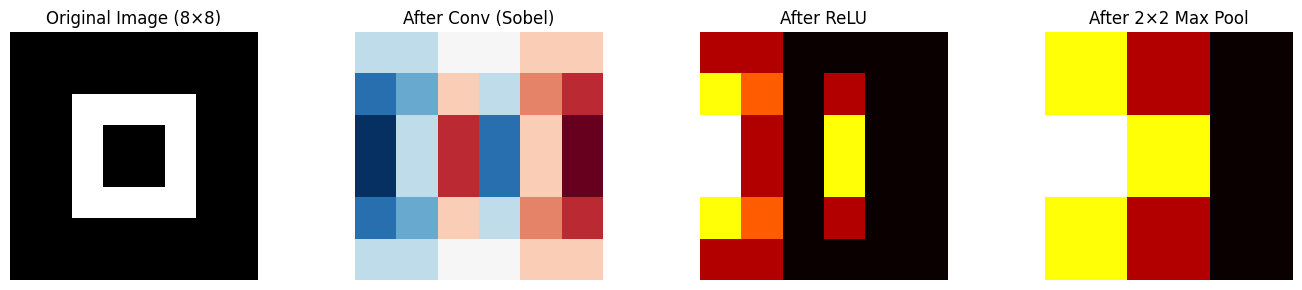

In [5]:
# --- Visualise the pipeline ---
fig, axes = plt.subplots(1, 4, figsize=(14, 3))

axes[0].imshow(image, cmap='gray')
axes[0].set_title('Original Image (8×8)')

axes[1].imshow(fmap, cmap='RdBu')
axes[1].set_title('After Conv (Sobel)')

axes[2].imshow(fmap_relu, cmap='hot')
axes[2].set_title('After ReLU')

axes[3].imshow(pooled, cmap='hot')
axes[3].set_title('After 2×2 Max Pool')

for ax in axes:
    ax.axis('off')

plt.tight_layout()
plt.show()

### **Observations**

> Answer the following after running your code:
>
> 1. What does the feature map *after Conv* tell you about the image? Where are the high-magnitude responses, and why?
> 2. What does ReLU remove, and why is that useful here?
> 3. The pooled map is much smaller — does it still capture the essential structure of the original image? What is lost?

1. The feature map after Conv highlights areas of the image that strongly activate the filter, which likely correspond to edges or specific patterns the kernel is designed to detect. High-magnitude responses indicate regions where the filter's learned features are present in the image.

2. ReLU removes negative values from the feature map setting them to zero. This is useful because it introduces non-linearity into the model allowing it to learn more complex patterns. Additionally it helps to mitigate the vanishing gradient problem during training by ensuring that gradients can flow through the network.

3. The pooled map captures the most salient features of the original image while significantly reducing spatial dimensions. however it loses fine-grained details and precise spatial relationships between features, which may be important for tasks that require high-resolution information.
